This Jupyter notebook provides some analysis of the influence of open cluster parameters on the binary fraction. Some of the figures from this notebook are also in our article.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats as stats
import warnings
warnings.filterwarnings('ignore')
from uncertainties import unumpy as unp
import matplotlib.colors as mcolors
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib as mpl
from matplotlib import ticker
from matplotlib import pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns

import sys
from pathlib import Path

sys.path.append(str(Path("../scripts").resolve()))
from functions import *


palette = plt.cm.viridis
font = {'color':  'black', 'weight': 'normal','size': 14}
font_cb = {'color':  'black', 'weight': 'normal','size': 12}
labelsize=12

In [2]:
df = pd.read_csv('../results/results.csv', index_col='Cluster')
data = pd.read_csv('../results/data.csv', index_col='Cluster')

# Age and binary fraction

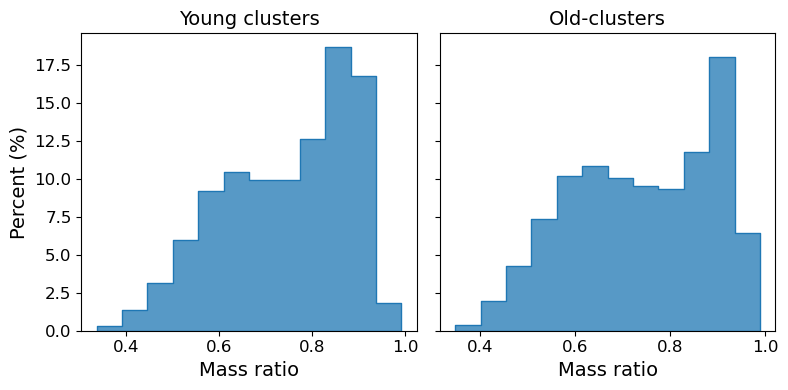

KS test: stat = 0.0741, p = 4.99e-67
Distribuições distintas

Mann–Whitney U test: U = 445784324.0000, p = 2.7345e-01
Não há evidência de que são diferentes

Anderson–Darling test: stat = 216.4039, p = 1.0000e-03
Distribuições distintas



In [3]:
aux = data.copy()


aux['age'] = df['age']
aux = aux[aux.q > 0.]
aux['age_group'] = np.where(aux['age'] <= 8, 'Young clusters', 'Old-clusters')


fig, axs = plt.subplots(1,2, figsize=(8, 4), sharey=True)
age_order = ['Young clusters', 'Old-clusters']

for i, group in enumerate(age_order):
    subset = aux[aux.age_group == group]
    
    sns.histplot(data=subset, x='q',element='step', stat='percent',ax=axs[i], bins = 12)
    axs[i].set_title(age_order[i], fontdict= font)
    axs[i].tick_params(labelsize=labelsize)
    axs[i].set_xlabel('Mass ratio', fontdict=font)


axs[0].set_ylabel('Percent (%)', fontdict=font)
plt.tight_layout()
plt.savefig('../Figures/hist_mass_ratio_age', bbox_inches='tight', dpi = 300)
plt.show()

young = aux[aux['age_group'] == 'Young clusters']['q']
old = aux[aux['age_group'] == 'Old-clusters']['q']
statistical_test(young,old)

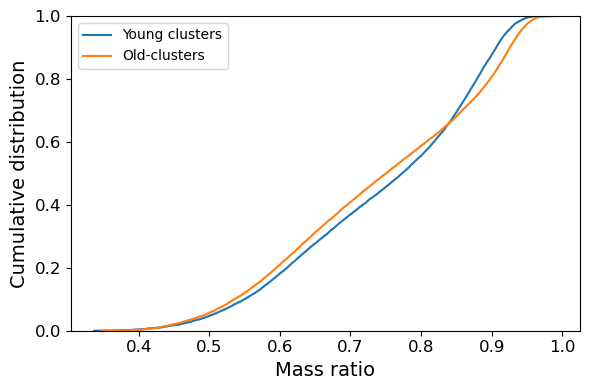

In [4]:
fig, axs = plt.subplots(figsize=(6, 4), sharey=True)

for i, group in enumerate(age_order):
    subset = aux[aux.age_group == group]
    
    sns.ecdfplot(data=subset,x='q',label = group)
    
    axs.tick_params(labelsize=labelsize)
    axs.set_xlabel('Mass ratio', fontdict=font)

axs.set_ylabel('Cumulative distribution', fontdict=font)

plt.tight_layout()
plt.legend()
plt.savefig('../Figures/cdf_q_age.png', bbox_inches='tight', dpi=300)
plt.show()

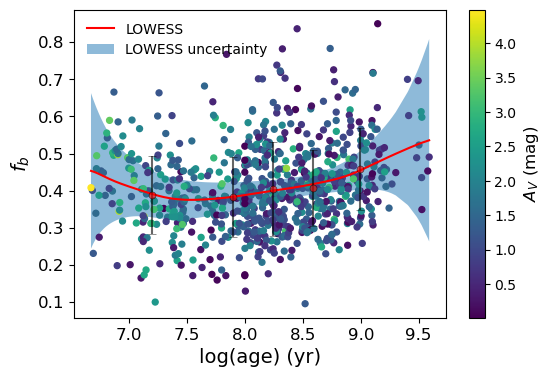

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))

X = df['age']
Y = df['bin_frac_corr']

order = np.argsort(X.values)
y_sm, y_std = lowess(X.values, Y.values, f=0.3)
ax.plot(X.values[order], y_sm[order], color='red', label='LOWESS')
ax.fill_between(X.values[order],
                np.where((y_sm[order] - 1.96*y_std[order])<0, 0 , y_sm[order] - 1.96*y_std[order]),
                np.where((y_sm[order] + 1.96*y_std[order])>1, 1 , y_sm[order] + 1.96*y_std[order]), 
                alpha=0.5, label='LOWESS uncertainty')

sc = ax.scatter(
        X,
        Y,
        c=df['Av'],
        cmap=palette,
        s=18
    )

df_sorted = df.sort_values(by=X.name)

df_sorted['bin'] = pd.qcut(df_sorted[X.name], 5, duplicates='drop')

grouped = df_sorted.groupby('bin')

x = grouped[X.name].mean().values
y = grouped[Y.name].mean().values
y_err = grouped[Y.name].std().values
    
ax.errorbar(x,y,yerr = y_err, fmt='o',capsize=3, c='red', alpha=0.6, ms=5, ecolor = 'k', mec='k', mew=0.5,)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r'$A_V$ (mag)', fontdict=font_cb)

ax.set_xlabel('log(age) (yr)', fontdict=font)
ax.set_ylabel(r'$f_b$', fontdict=font)
ax.tick_params(labelsize=labelsize)
ax.legend(frameon=False, loc = 'upper left')
plt.savefig('../Figures/dist_fb_age.png', bbox_inches='tight', dpi=300)
plt.show()


## Same analysis for binaries with q>0.5

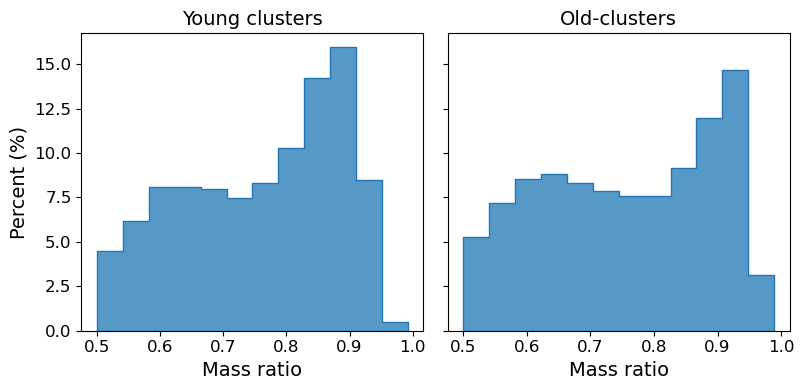

KS test: stat = 0.0795, p = 2.80e-73
Distribuições distintas

Mann–Whitney U test: U = 396493782.0000, p = 3.4202e-01
Não há evidência de que são diferentes

Anderson–Darling test: stat = 220.0024, p = 1.0000e-03
Distribuições distintas



In [6]:
aux = data.copy()


aux['age'] = df['age']
aux = aux[aux.q > 0.5]
aux['age_group'] = np.where(aux['age'] <= 8, 'Young clusters', 'Old-clusters')


fig, axs = plt.subplots(1,2, figsize=(8, 4), sharey=True)
age_order = ['Young clusters', 'Old-clusters']

for i, group in enumerate(age_order):
    subset = aux[aux.age_group == group]
    
    sns.histplot(data=subset, x='q',element='step', stat='percent',ax=axs[i], bins = 12)
    axs[i].set_title(age_order[i], fontdict= font)
    axs[i].tick_params(labelsize=labelsize)
    axs[i].set_xlabel('Mass ratio', fontdict=font)


axs[0].set_ylabel('Percent (%)', fontdict=font)
plt.tight_layout()
plt.show()

young = aux[aux['age_group'] == 'Young clusters']['q']
old = aux[aux['age_group'] == 'Old-clusters']['q']
statistical_test(young,old)


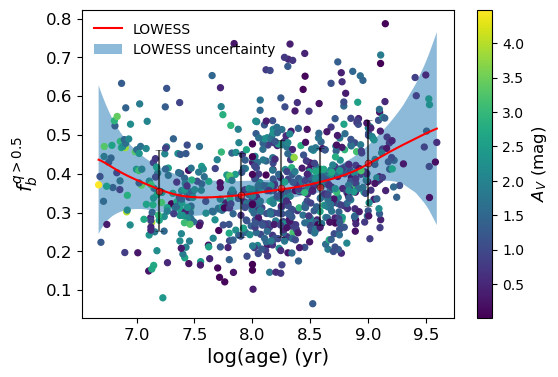

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))

X = df['age']
Y = df['bin_frac_05_corr']

order = np.argsort(X.values)
y_sm, y_std = lowess(X.values, Y.values, f=0.3)
ax.plot(X.values[order], y_sm[order], color='red', label='LOWESS')
ax.fill_between(X.values[order],
                np.where((y_sm[order] - 1.96*y_std[order])<0, 0 , y_sm[order] - 1.96*y_std[order]),
                np.where((y_sm[order] + 1.96*y_std[order])>1, 1 , y_sm[order] + 1.96*y_std[order]), 
                alpha=0.5, label='LOWESS uncertainty')

sc = ax.scatter(
        X,
        Y,
        c=df['Av'],
        cmap=palette,
        s=18
    )

df_sorted = df.sort_values(by=X.name)

df_sorted['bin'] = pd.qcut(df_sorted[X.name], 5, duplicates='drop')

grouped = df_sorted.groupby('bin')

x = grouped[X.name].mean().values
y = grouped[Y.name].mean().values
y_err = grouped[Y.name].std().values
    
ax.errorbar(x,y,yerr = y_err, fmt='o',capsize=3, c='red', alpha=0.6, ms=5, ecolor = 'k', mec='k', mew=0.5,)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r'$A_V$ (mag)', fontdict=font_cb)

ax.set_xlabel('log(age) (yr)', fontdict=font)
ax.set_ylabel(r'$f_b^{q>0.5}$', fontdict=font)
ax.tick_params(labelsize=labelsize)
ax.legend(frameon=False, loc = 'upper left')
plt.show()


# Metallicity and binary fraction

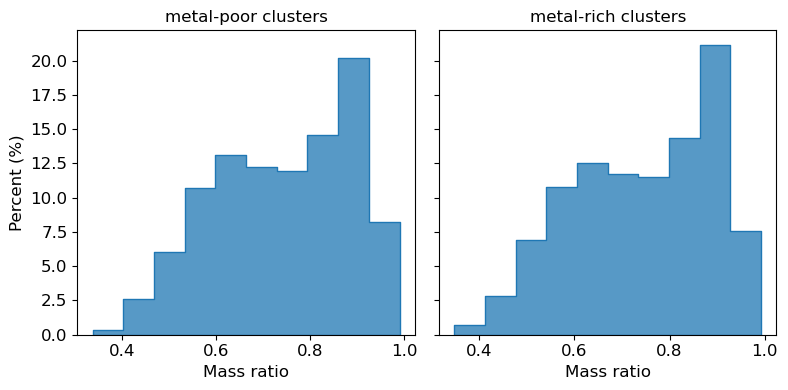

KS test: stat = 0.0190, p = 4.36e-05
Distribuições distintas

Mann–Whitney U test: U = 467589230.0000, p = 6.0292e-03
Distribuições distintas

Anderson–Darling test: stat = 8.1683, p = 1.0000e-03
Distribuições distintas



In [138]:
aux = data.copy()


aux['FeH'] = df['FeH']
aux = aux[aux.q > 0]
aux['FeH_group'] = np.where(aux['FeH'] < 0, 'metal-poor clusters', 'metal-rich clusters')


fig, axs = plt.subplots(1,2, figsize=(8, 4), sharey=True)
FeH_order = ['metal-poor clusters', 'metal-rich clusters']

for i, group in enumerate(FeH_order):
    subset = aux[aux.FeH_group == group]
    
    sns.histplot(data=subset, x='q',element='step', stat='percent',ax=axs[i], bins = 10)
    axs[i].set_title(FeH_order[i], fontdict= font)
    axs[i].tick_params(labelsize=labelsize)
    axs[i].set_xlabel('Mass ratio', fontdict=font)


axs[0].set_ylabel('Percent (%)', fontdict=font)
plt.tight_layout()
#plt.savefig('../Figures/' ,bbox_inches='tight', dpi=300)
plt.show()

metal_poor = aux[aux['FeH_group'] == 'metal-poor clusters']['q']
metal_rich = aux[aux['FeH_group'] == 'metal-rich clusters']['q']
statistical_test(metal_poor,metal_rich)

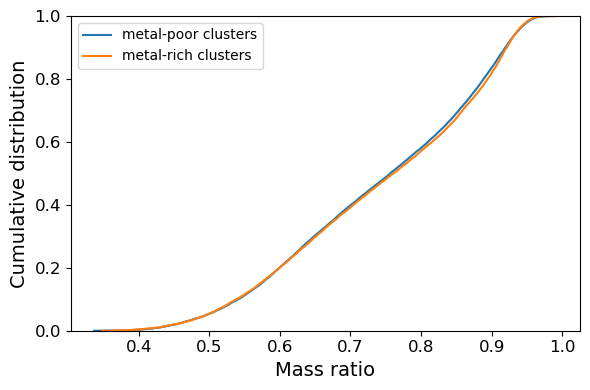

In [9]:
fig, axs = plt.subplots(figsize=(6, 4), sharey=True)

for i, group in enumerate(FeH_order):
    subset = aux[aux.FeH_group == group]
    
    sns.ecdfplot(data=subset,x='q',label = group)
    
    axs.tick_params(labelsize=labelsize)
    axs.set_xlabel('Mass ratio', fontdict=font)

axs.set_ylabel('Cumulative distribution', fontdict=font)

plt.tight_layout()
plt.legend()
plt.savefig('../Figures/cdf_q_FeH.png', bbox_inches='tight', dpi=300)
plt.show()

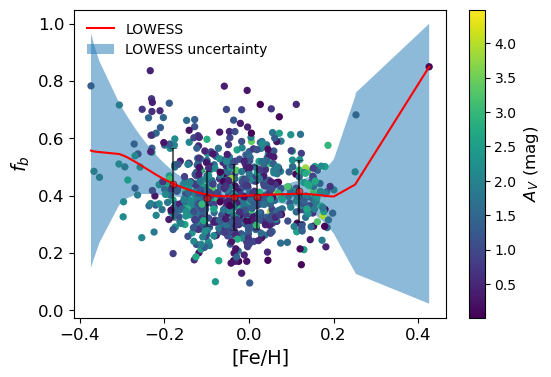

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))

X = df['FeH']
Y = df['bin_frac_corr']

order = np.argsort(X.values)
y_sm, y_std = lowess(X.values, Y.values, f=0.3)
ax.plot(X.values[order], y_sm[order], color='red', label='LOWESS')
ax.fill_between(X.values[order],
                np.where((y_sm[order] - 1.96*y_std[order])<0, 0 , y_sm[order] - 1.96*y_std[order]),
                np.where((y_sm[order] + 1.96*y_std[order])>1, 1 , y_sm[order] + 1.96*y_std[order]), 
                alpha=0.5, label='LOWESS uncertainty')

sc = ax.scatter(
        X,
        Y,
        c=df['Av'],
        cmap=palette,
        s=18
    )

df_sorted = df.sort_values(by=X.name)

df_sorted['bin'] = pd.qcut(df_sorted[X.name], 5, duplicates='drop')

grouped = df_sorted.groupby('bin')

x = grouped[X.name].mean().values
y = grouped[Y.name].mean().values
y_err = grouped[Y.name].std().values
    
ax.errorbar(x,y,yerr = y_err, fmt='o',capsize=3, c='red', alpha=0.6, ms=5, ecolor = 'k', mec='k', mew=0.5,)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r'$A_V$ (mag)', fontdict=font_cb)

ax.set_xlabel('[Fe/H]', fontdict=font)
ax.set_ylabel(r'$f_b$', fontdict=font)
ax.tick_params(labelsize=labelsize)
ax.legend(frameon=False, loc = 'upper left')
plt.savefig('../Figures/dist_fb_FeH.png', bbox_inches='tight', dpi=300)
plt.show()


## Binaries with q>0.5

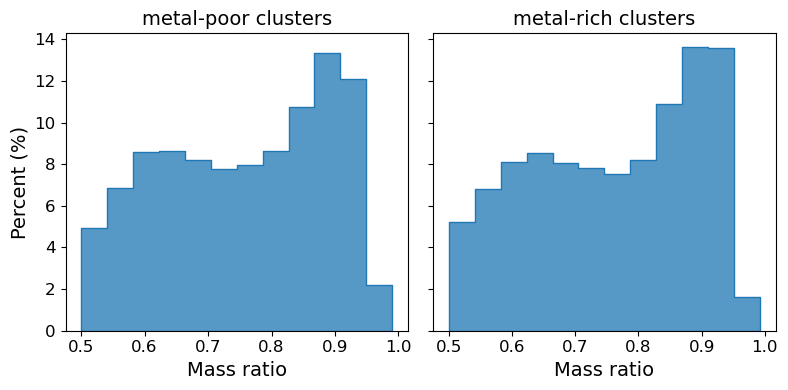

KS test: stat = 0.0201, p = 2.20e-05
Distribuições distintas

Mann–Whitney U test: U = 417827564.0000, p = 2.3265e-03
Distribuições distintas

Anderson–Darling test: stat = 9.1729, p = 1.0000e-03
Distribuições distintas



In [11]:
aux = data.copy()


aux['FeH'] = df['FeH']
aux = aux[aux.q > 0.5]
aux['FeH_group'] = np.where(aux['FeH'] < 0, 'metal-poor clusters', 'metal-rich clusters')


fig, axs = plt.subplots(1,2, figsize=(8, 4), sharey=True)
FeH_order = ['metal-poor clusters', 'metal-rich clusters']

for i, group in enumerate(FeH_order):
    subset = aux[aux.FeH_group == group]
    
    sns.histplot(data=subset, x='q',element='step', stat='percent',ax=axs[i], bins = 12)
    axs[i].set_title(FeH_order[i], fontdict= font)
    axs[i].tick_params(labelsize=labelsize)
    axs[i].set_xlabel('Mass ratio', fontdict=font)


axs[0].set_ylabel('Percent (%)', fontdict=font)
plt.tight_layout()
plt.show()

metal_poor = aux[aux['FeH_group'] == 'metal-poor clusters']['q']
metal_rich = aux[aux['FeH_group'] == 'metal-rich clusters']['q']
statistical_test(metal_poor,metal_rich)

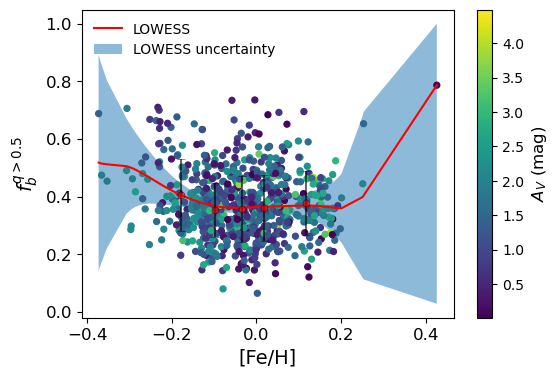

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))

X = df['FeH']
Y = df['bin_frac_05_corr']

order = np.argsort(X.values)
y_sm, y_std = lowess(X.values, Y.values, f=0.3)
ax.plot(X.values[order], y_sm[order], color='red', label='LOWESS')
ax.fill_between(X.values[order],
                np.where((y_sm[order] - 1.96*y_std[order])<0, 0 , y_sm[order] - 1.96*y_std[order]),
                np.where((y_sm[order] + 1.96*y_std[order])>1, 1 , y_sm[order] + 1.96*y_std[order]), 
                alpha=0.5, label='LOWESS uncertainty')

sc = ax.scatter(
        X,
        Y,
        c=df['Av'],
        cmap=palette,
        s=18
    )

df_sorted = df.sort_values(by=X.name)

df_sorted['bin'] = pd.qcut(df_sorted[X.name], 5, duplicates='drop')

grouped = df_sorted.groupby('bin')

x = grouped[X.name].mean().values
y = grouped[Y.name].mean().values
y_err = grouped[Y.name].std().values
    
ax.errorbar(x,y,yerr = y_err, fmt='o',capsize=3, c='red', alpha=0.6, ms=5, ecolor = 'k', mec='k', mew=0.5,)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r'$A_V$ (mag)', fontdict=font_cb)

ax.set_xlabel('[Fe/H]', fontdict=font)
ax.set_ylabel(r'$f_b^{q>0.5}$', fontdict=font)
ax.tick_params(labelsize=labelsize)
ax.legend(frameon=False, loc = 'upper left')
plt.show()


# Dynamical parameters

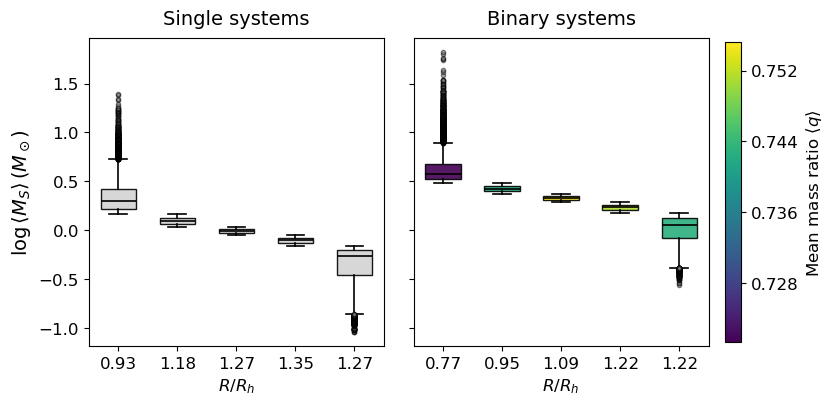

In [112]:
def styled_boxplot(ax, data, box_labels, title, color_by_q=True):

    bp = ax.boxplot(
        data,
        patch_artist=True,
        widths=0.6,
        showfliers=True,
        flierprops=dict(
            marker='o',
            markersize=3,
            markerfacecolor='gray',
            markeredgecolor='black',
            alpha=0.5
        )
    )

    for i, patch in enumerate(bp['boxes']):
        if color_by_q:
            patch.set_facecolor(cmap(norm(box_q[i])))
        else:
            patch.set_facecolor('lightgray')
        patch.set_edgecolor('black')
        patch.set_alpha(0.9)

    for element in ['whiskers', 'caps', 'medians']:
        for item in bp[element]:
            item.set_color('black')
            item.set_linewidth(1.2)

    ax.set_xticklabels(box_labels, fontsize=12)
    ax.set_xlabel(r'$R / R_h$', fontsize=12)
    ax.set_title(title, fontsize=14, pad=10)

    ax.tick_params(axis='y', labelsize=12)
    ax.invert_xaxis()

    return bp


data['mass_system'] = data['mass'] + data['comp_mass']

binarias = data[data.q>0]
binarias =  binarias.sort_values(by='mass_system').reset_index(drop=True)

singles = data[data.q==0]
singles = singles.sort_values(by='mass_system').reset_index(drop=True)

n_div = 5

indices_singles = np.array_split(singles.index, n_div)
indices_binarias = np.array_split(binarias.index, n_div)

subconjuntos_singles = [singles.iloc[idx] for idx in indices_singles]
subconjuntos_binarias = [binarias.iloc[idx] for idx in indices_binarias]

box_mass_bin = []    
box_q = []
box_labels_bin = []  

box_mass_sig = []
box_labels_sig = []

for i in range(n_div):
    rrh_mean = subconjuntos_binarias[i]['r/rh'].median()
    q_mean = subconjuntos_binarias[i]['q'].mean()
    m_vals = subconjuntos_binarias[i]['mass_system'].values

    box_mass_bin.append(np.log10(m_vals))
    box_q.append(q_mean)
    box_labels_bin.append(f'{rrh_mean:.2f}')

    rrh_mean = subconjuntos_singles[i]['r/rh'].median()

    m_vals = subconjuntos_singles[i]['mass_system'].values

    box_mass_sig.append(np.log10(m_vals))
    box_labels_sig.append(f'{rrh_mean:.2f}')

fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey=True, gridspec_kw={'hspace': 0.2, 'wspace': 0.1})
norm = mcolors.Normalize(vmin=np.min(box_q), vmax=np.max(box_q))
cmap = cm.viridis

styled_boxplot(
    ax[1],
    box_mass_bin,
    box_labels_bin,
    title='Binary systems'
)

styled_boxplot(
    ax[0],
    box_mass_sig,
    box_labels_sig,
    title='Single systems',
    color_by_q=False
)

ax[0].set_ylabel(
    r'$\log\langle M_S \rangle\,(M_\odot)$',
    fontsize=14
)

cax = fig.add_axes([0.92, 0.12, 0.02, 0.75])  # [left, bottom, width, height]
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cax)
cbar.set_label(r'Mean mass ratio $\langle q \rangle$', fontsize=12)
cbar.ax.tick_params(labelsize=12)
cbar.locator = ticker.MaxNLocator(nbins=5)
cbar.update_ticks()

plt.tight_layout()
#plt.savefig('Figures/dist_radial_massa.png', bbox_inches='tight', dpi=300)
plt.show()


In [137]:
print(f'Median values r/Rh for binary box_mass_sigstars: {data[data['q']>0]['r/rh'].median():.2f}')
print(f'Median values r/Rh for single stars: {data[data['q']==0]['r/rh'].median():.2f}')


Median values r/Rh for binary box_mass_sigstars: 1.04
Median values r/Rh for single stars: 1.20


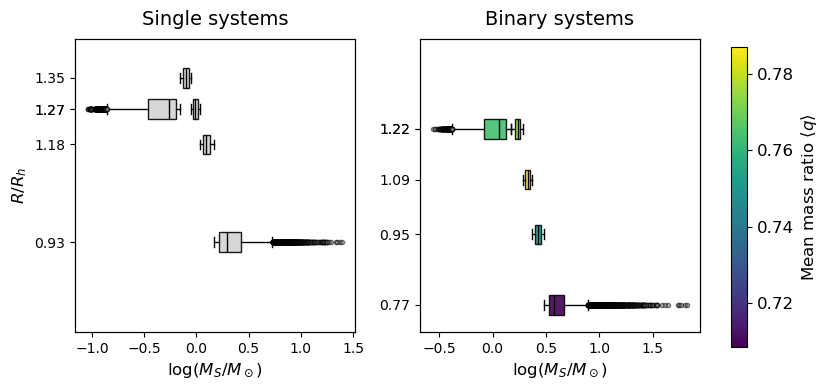

In [136]:
def styled_boxplot(ax, data, positions, title, box_q=None, color_by_q=True, show_ylabel=False):

    bp = ax.boxplot(data, patch_artist=True,widths=0.05,positions=positions,showfliers=True,  orientation='horizontal',
                    flierprops=dict(marker='o',markersize=3,markerfacecolor='gray',markeredgecolor='black',alpha=0.5),)

    for i, patch in enumerate(bp['boxes']):
        if color_by_q and box_q is not None:
            patch.set_facecolor(cmap(norm(box_q[i])))
        else:
            patch.set_facecolor('lightgray')

        patch.set_edgecolor('black')
        patch.set_alpha(0.9)

    # Estilo whiskers, caps e medianas
    for element in ['whiskers', 'caps', 'medians']:
        for item in bp[element]:
            item.set_color('black')
            item.set_linewidth(1)

    ax.set_title(title, fontsize=14, pad=10)

    if show_ylabel:
        ax.set_ylabel(r'$R / R_h$', fontdict=font)
        ax.set_yticks(positions)
        ax.set_yticklabels([f'{x:.2f}' for x in positions], fontsize=12)
    else:
        ax.tick_params(axis='y', left=False, labelleft=False)

    return bp


data['mass_system'] = data['mass'] + data['comp_mass']

binarias = (
    data[data.q > 0]
    .sort_values(by='mass_system')
    .reset_index(drop=True)
)

singles = (
    data[data.q == 0]
    .sort_values(by='mass_system')
    .reset_index(drop=True)
)

n_div = 5

indices_singles = np.array_split(singles.index, n_div)
indices_binarias = np.array_split(binarias.index, n_div)

subconjuntos_singles = [singles.iloc[idx] for idx in indices_singles]
subconjuntos_binarias = [binarias.iloc[idx] for idx in indices_binarias]

box_mass_bin = []
box_q = []
box_positions_bin = []

box_mass_sig = []
box_positions_sig = []


for i in range(n_div):

    # binaries
    rrh_med = subconjuntos_binarias[i]['r/rh'].median()
    q_mean = subconjuntos_binarias[i]['q'].median()
    m_vals = subconjuntos_binarias[i]['mass_system'].values

    box_mass_bin.append(np.log10(m_vals))
    box_q.append(q_mean)
    box_positions_bin.append(round(rrh_med, 2))

    # singles
    rrh_med = subconjuntos_singles[i]['r/rh'].median()
    m_vals = subconjuntos_singles[i]['mass_system'].values

    box_mass_sig.append(np.log10(m_vals))
    box_positions_sig.append(round(rrh_med, 2))



fig, ax = plt.subplots(1, 2,figsize=(8, 4),sharey=True,)

norm = mcolors.Normalize(vmin=np.min(box_q),vmax=np.max(box_q))

cmap = cm.viridis



styled_boxplot(ax[0],box_mass_sig,positions=box_positions_sig,title='Single systems',color_by_q=False, show_ylabel=False)
styled_boxplot(ax[1],box_mass_bin,positions=box_positions_bin,title='Binary systems',box_q=box_q,  show_ylabel=False)

ax[0].set_ylim(0.7, 1.45)

ax[0].set_yticks([])
ax0 = ax[0].twinx()
ax0.set_ylim(ax[0].get_ylim())
ax0.set_yticks(box_positions_sig)
ax0.set_yticklabels([f'{x:.2f}' for x in box_positions_sig],fontsize=10)

ax0.yaxis.tick_left()
ax0.yaxis.set_label_position("left")

ax0.set_ylabel(r'$R / R_h$', fontdict=font)


ax[1].set_yticks([])
ax1 = ax[1].twinx()
ax1.set_ylim(ax[1].get_ylim())
ax1.set_yticks(box_positions_bin)
ax1.set_yticklabels([f'{x:.2f}' for x in box_positions_bin],fontsize=10)

ax1.yaxis.tick_left()
ax1.yaxis.set_label_position("left")





ax[0].set_xlabel(r'$\log(M_S/M_\odot)$',fontdict=font)

ax[1].set_xlabel(r'$\log(M_S/M_\odot)$',fontdict=font)

cax = fig.add_axes([0.92, 0.12, 0.02, 0.75])

sm = cm.ScalarMappable(cmap=cmap,norm=norm)

sm.set_array([])

cbar = fig.colorbar(sm, cax=cax)
cbar.set_label(r'Mean mass ratio $\langle q \rangle$',fontdict=font)

cbar.ax.tick_params(labelsize=12)
cbar.locator = ticker.MaxNLocator(nbins=5)
cbar.formatter = ticker.FormatStrFormatter('%.2f')
cbar.update_ticks()
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.savefig('../Figures/dist_radial_massa.png', bbox_inches='tight', dpi=300)

plt.show()

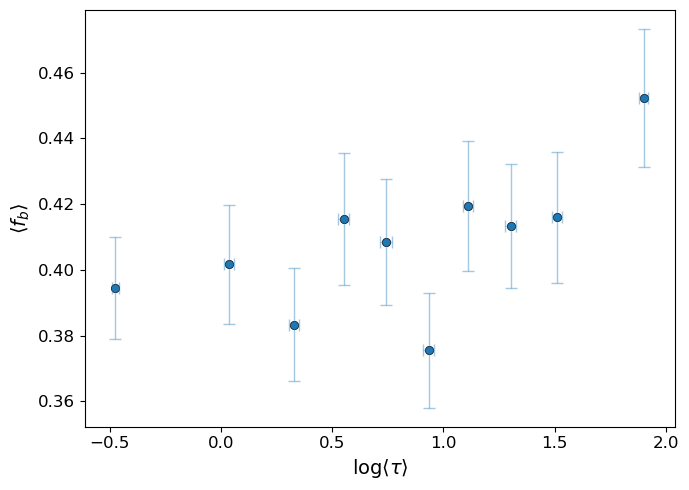

In [17]:


n_div = 10

# 1. Primeiro, ordenamos o DataFrame e salvamos em uma variável
df_sorted = df.sort_values(by='tau')

# 2. Dividimos posições numéricas inteiras (0, 1, 2... até o tamanho do df)
posicoes = np.array_split(np.arange(len(df_sorted)), n_div)

# 3. Resgatamos os subconjuntos usando iloc no DataFrame ordenado
subconjuntos = [df_sorted.iloc[pos] for pos in posicoes]

tau_mean = []
bin_frac_mean = []

# O loop continua igual, o uso do unp está perfeito!
for i in range(len(subconjuntos)):
    tau_vals = subconjuntos[i]["tau"].values
    tau_errs = subconjuntos[i]["e_tau"].values
    tau_ufloats = unp.uarray(tau_vals, tau_errs)
    tau_mean.append(unp.log10(tau_ufloats).mean())

    # bin_frac y er_bin_frac
    bf_vals = subconjuntos[i]["bin_frac_corr"].values
    bf_errs = subconjuntos[i]["er_bin_frac"].values
    bf_ufloats = unp.uarray(bf_vals, bf_errs)
    bin_frac_mean.append(bf_ufloats.mean())

tau_mean = np.array(tau_mean)
bin_frac_mean = np.array(bin_frac_mean)

# Separando valores nominais e erros para o plot
x = unp.nominal_values(tau_mean)
y = unp.nominal_values(bin_frac_mean)
xerr = unp.std_devs(tau_mean)
yerr = unp.std_devs(bin_frac_mean)

# Plotagem
fig, ax = plt.subplots(figsize=(7, 5))

# Scatterplot para os dados com propagação de erro
sns.scatterplot(x=x, y=y, ax=ax, color='tab:blue', edgecolor='k')

# Barras de erro
ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='none', ecolor='tab:blue', alpha=0.4, capsize=4, elinewidth=1)

# Assumindo que 'font' e 'labelsize' já foram definidos
ax.set_xlabel(r"log$\langle \tau \rangle$", fontdict=font)
ax.set_ylabel(r"$\langle f_b \rangle$", fontdict=font)
ax.tick_params(axis='both', labelsize=labelsize)

plt.tight_layout()
plt.savefig('../Figures/fb_tau.png', dpi=300)
plt.show()